# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [54]:
df = pd.read_csv("../data/checker_submits.csv",parse_dates=['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [55]:
categorical_cols = ['uid', 'labname']
continuous_cols = ['numTrials', 'hour']
target_col = 'dayofweek'

In [56]:
ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = ohe.fit_transform(df[categorical_cols])
X_categorical.shape

(1686, 41)

In [57]:
ohe_names = ohe.get_feature_names(categorical_cols)
df_categorical = pd.DataFrame(X_categorical, columns=ohe_names)
df_categorical

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [58]:
scaler = StandardScaler()
X_continuous = scaler.fit_transform(df[continuous_cols])

In [59]:
df_continuous = pd.DataFrame(X_continuous, columns=continuous_cols, index=df.index)
df_continuous

,numTrials,hour
0,-0.788667,-2.562352
1,-0.756764,-2.562352
2,-0.724861,-2.562352
3,-0.692958,-2.562352
4,-0.661055,-2.562352
...,...,...
1681,-0.533442,0.945382
1682,-0.629151,0.945382
1683,-0.597248,0.945382
1684,-0.565345,0.945382


In [60]:
df_processed = pd.concat([df_continuous, df_categorical], axis=1)
df_processed['dayofweek'] = df['dayofweek'].values
df_processed

,numTrials,hour,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,...,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,dayofweek
0,-0.788667,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
1,-0.756764,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
2,-0.724861,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
3,-0.692958,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
4,-0.661055,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
1682,-0.629151,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
1683,-0.597248,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3
1684,-0.565345,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3


In [61]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   numTrials         1686 non-null   float64
 1   hour              1686 non-null   float64
 2   uid_user_0        1686 non-null   float64
 3   uid_user_1        1686 non-null   float64
 4   uid_user_10       1686 non-null   float64
 5   uid_user_11       1686 non-null   float64
 6   uid_user_12       1686 non-null   float64
 7   uid_user_13       1686 non-null   float64
 8   uid_user_14       1686 non-null   float64
 9   uid_user_15       1686 non-null   float64
 10  uid_user_16       1686 non-null   float64
 11  uid_user_17       1686 non-null   float64
 12  uid_user_18       1686 non-null   float64
 13  uid_user_19       1686 non-null   float64
 14  uid_user_2        1686 non-null   float64
 15  uid_user_20       1686 non-null   float64
 16  uid_user_21       1686 non-null   float64


In [62]:
df_processed.to_csv('../data/dayofweek.csv', index=False)

In [63]:
most_popular = df_processed['dayofweek'].mode()[0]
naive_accuracy = (df_processed['dayofweek'] == most_popular).mean()
naive_accuracy

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [64]:
X = df_processed.drop(columns=['dayofweek'])
y = df_processed['dayofweek']

In [65]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000) #чтобы не было ошибки нехватки иттераций
logreg.fit(X, y)
y_pred = logreg.predict(X)
y_pred

array([4, 4, 4, ..., 3, 3, 3], dtype=int64)

In [66]:
accuracy = accuracy_score(y, y_pred)
accuracy

0.6405693950177936

In [67]:
def plot_top_features(model, feature_names, n_top=10):
    # coef_ имеет shape (n_classes, n_features)
    # сумма по всем классам т.к axis=0
    importances = np.abs(model.coef_).max(axis=0)
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False) #к меньш сумме
    top_n = feature_importance.head(n_top)

    plt.figure(figsize=(10, 6))
    plt.barh(top_n['feature'], top_n['importance'], color='steelblue') #название, ширина по сумме
    plt.title(f'Top {n_top} most important features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return top_n

In [68]:
feature_names = X.columns.tolist() #чтобы передать в df
feature_names


['numTrials',
 'hour',
 'uid_user_0',
 'uid_user_1',
 'uid_user_10',
 'uid_user_11',
 'uid_user_12',
 'uid_user_13',
 'uid_user_14',
 'uid_user_15',
 'uid_user_16',
 'uid_user_17',
 'uid_user_18',
 'uid_user_19',
 'uid_user_2',
 'uid_user_20',
 'uid_user_21',
 'uid_user_22',
 'uid_user_23',
 'uid_user_24',
 'uid_user_25',
 'uid_user_26',
 'uid_user_27',
 'uid_user_28',
 'uid_user_29',
 'uid_user_3',
 'uid_user_30',
 'uid_user_31',
 'uid_user_4',
 'uid_user_6',
 'uid_user_7',
 'uid_user_8',
 'labname_code_rvw',
 'labname_lab02',
 'labname_lab03',
 'labname_lab03s',
 'labname_lab05s',
 'labname_laba04',
 'labname_laba04s',
 'labname_laba05',
 'labname_laba06',
 'labname_laba06s',
 'labname_project1']

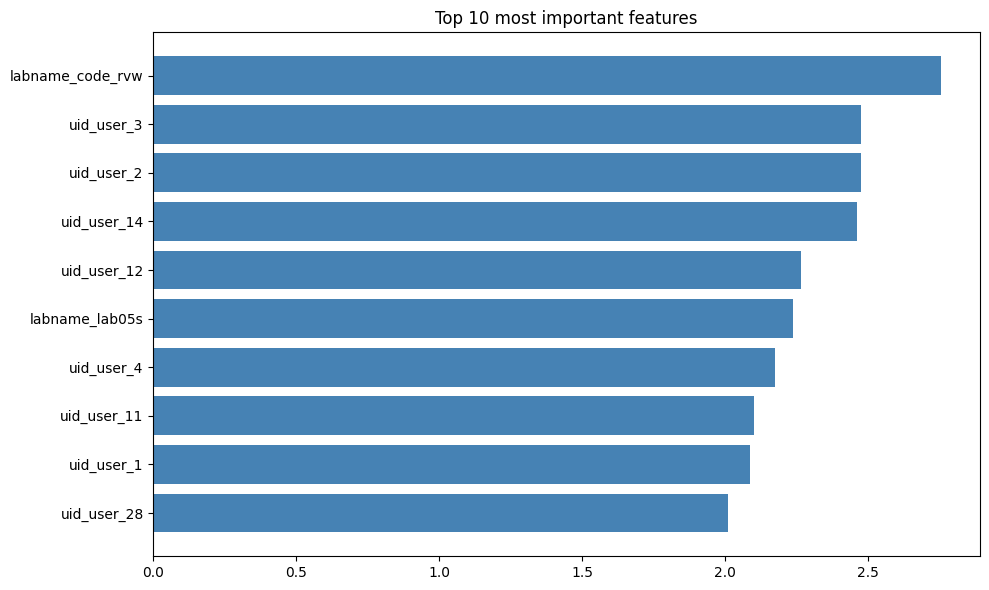

In [69]:
top_10 = plot_top_features(logreg, feature_names, n_top=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [70]:
svc_linear_model = SVC(kernel='linear', probability=True, random_state=21)
svc_linear_model.fit(X, y)

predictions = svc_linear_model.predict(X)
svc_linear_model_accuracy = accuracy_score(y, predictions)

In [71]:
print(f'SVC linear model accuracy: {svc_linear_model_accuracy}')

kernels_name = ['rbf', 'poly', 'sigmoid']
for idx, kernel_name in enumerate(kernels_name):
    svc_model = SVC(kernel=kernel_name, probability=True, random_state=21)
    svc_model.fit(X, y)
    predictions = svc_model.predict(X)
    svc_model_accuracy = accuracy_score(y, predictions)
    print(f'SVC {kernels_name[idx]} model accuracy: {svc_model_accuracy}')

SVC linear model accuracy: 0.702846975088968
SVC rbf model accuracy: 0.8558718861209964
SVC poly model accuracy: 0.8594306049822064
SVC sigmoid model accuracy: 0.3997627520759193


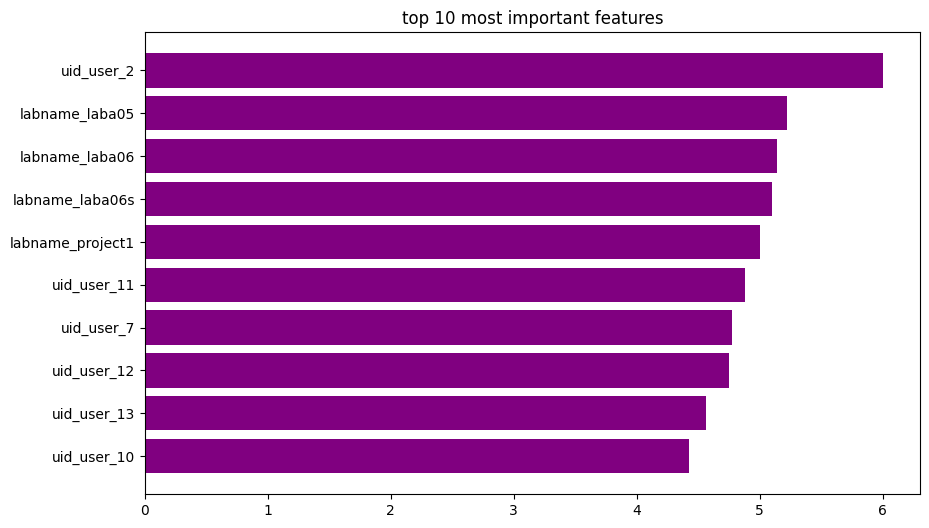

In [72]:
ovr_model = OneVsRestClassifier(svc_linear_model)
ovr_model.fit(X, y)
coefficient_list = []

for estimator in ovr_model.estimators_:
    coefficient_list.append(estimator.coef_[0])
coefficient_matrix = np.array(coefficient_list)

feature_importance = np.sum(np.abs(coefficient_matrix), axis=0)
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})

top_10_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_df['feature'], top_10_df['importance'], color='purple')
plt.gca().invert_yaxis()
plt.title('top 10 most important features')
plt.show()

In [73]:
top_10_df

,feature,importance
14,uid_user_2,6.002301
39,labname_laba05,5.225102
40,labname_laba06,5.140258
41,labname_laba06s,5.101857
42,labname_project1,4.999690
5,uid_user_11,4.878426
30,uid_user_7,4.774847
6,uid_user_12,4.748439
7,uid_user_13,4.563317
4,uid_user_10,4.428438


In [74]:
top_10_df.reset_index(drop=True)

,feature,importance
0,uid_user_2,6.002301
1,labname_laba05,5.225102
2,labname_laba06,5.140258
3,labname_laba06s,5.101857
4,labname_project1,4.999690
5,uid_user_11,4.878426
6,uid_user_7,4.774847
7,uid_user_12,4.748439
8,uid_user_13,4.563317
9,uid_user_10,4.428438


### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [75]:
tree_model = DecisionTreeClassifier(
    max_depth=10,        
    random_state=21
)

tree_model.fit(X, y)

predictions = tree_model.predict(X)
acc_tree = accuracy_score(y, predictions)
print(f"Accuracy score {acc_tree}")

Accuracy score 0.8196915776986952


In [76]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_model.fit(X, y)

predictions = tree_model.predict(X)
acc_tree = accuracy_score(y, predictions)
print(f"Accuracy score {acc_tree}")

Accuracy score 0.5516014234875445


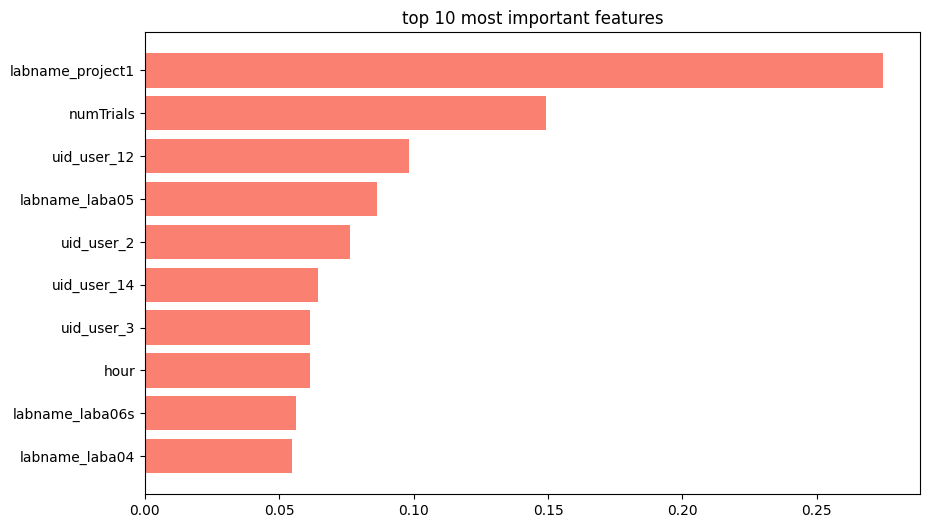

In [77]:
importances = tree_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values('importance', ascending=False)
top_10_df = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_df['feature'], top_10_df['importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('top 10 most important features')
plt.show()

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

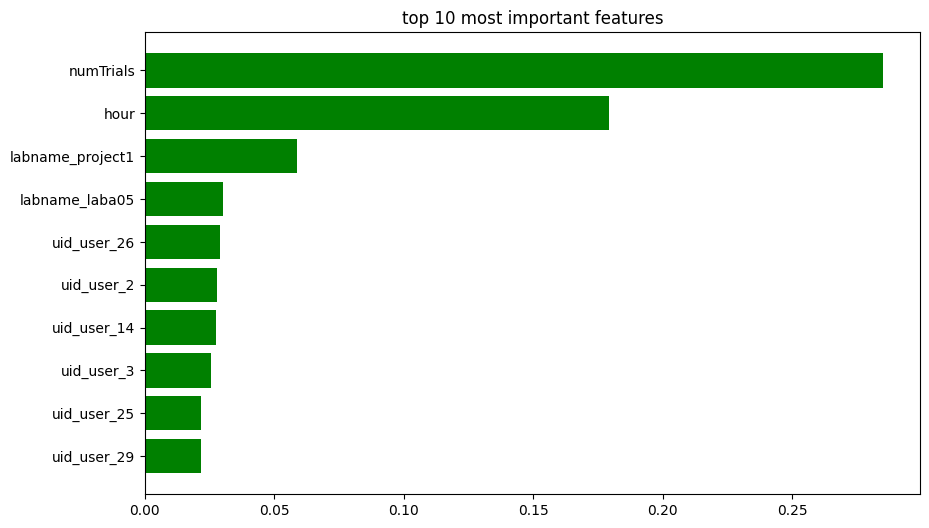

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    random_state=21
)
rf_model.fit(X, y)
feature_importance = rf_model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
top_10 = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['feature'], top_10['importance'], color="green")
plt.gca().invert_yaxis()
plt.title('top 10 most important features')
plt.show()